##Analisis Textual dan Sentimen
1.   Analisis tekstual adalah proses mengolah dan memahami isi dari teks (misalnya dari tweet, komentar, atau review) untuk menemukan pola, makna, atau informasi penting.
2.   Analisis sentimen adalah proses mengidentifikasi perasaan atau opini yang terkandung dalam teks digital. Analisis sentimen dapat digunakan untuk berbagai tujuan, seperti memantau media sosial,

## LATAR BELAKANG
Dalam era digital saat ini, media sosial seperti Twitter telah menjadi wadah utama bagi masyarakat untuk menyampaikan opini, pandangan politik, maupun respons terhadap isu-isu nasional. Perbincangan publik yang terjadi di media sosial mencerminkan suara dan aspirasi masyarakat secara real-time. Oleh karena itu, analisis terhadap data teks dari media sosial sangat penting untuk memahami persepsi masyarakat terhadap tokoh-tokoh politik, khususnya menjelang atau setelah peristiwa penting seperti debat capres, kampanye pemilu, maupun pengambilan keputusan publik.

Data yang digunakan dalam analisis ini merupakan kumpulan tweet yang menyebut nama tiga tokoh politik nasional yaitu Anies Baswedan, Ganjar Pranowo, dan Prabowo Subianto. Tweet-tweet tersebut mencerminkan berbagai pandangan dan sikap masyarakat yang dapat bersifat positif, negatif, maupun netral.

Melalui analisis tekstual, kita dapat mengetahui topik-topik utama yang sering dibahas oleh masyarakat terkait tokoh-tokoh tersebut, termasuk kata-kata atau frasa yang sering muncul. Sedangkan analisis sentimen akan membantu dalam mengukur persepsi publik—apakah sentimen terhadap masing-masing tokoh cenderung positif, negatif, atau netral.

Hasil dari analisis ini diharapkan dapat memberikan wawasan yang bermanfaat, tidak hanya bagi pihak-pihak yang berkepentingan dalam dunia politik, tetapi juga bagi peneliti dan pengamat media sosial yang ingin memahami dinamika opini publik secara lebih objektif dan berbasis data.

In [15]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
import seaborn as sns

In [16]:
df_anies1 = pd.read_csv('anies.csv')
df_prabowo1 = pd.read_csv('prabowo.csv')
df_ganjar1 = pd.read_csv('ganjar.csv')

In [17]:
df_anies = df_anies1[['full_text','username','created_at']]
df_prabowo = df_prabowo1[['full_text','username','created_at']]
df_ganjar = df_ganjar1[['full_text','username','created_at']]

In [18]:
df_anies.info()
df_prabowo.info()
df_ganjar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   full_text   514 non-null    object
 1   username    508 non-null    object
 2   created_at  514 non-null    object
dtypes: object(3)
memory usage: 12.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   full_text   503 non-null    object
 1   username    503 non-null    object
 2   created_at  503 non-null    object
dtypes: object(3)
memory usage: 11.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 423 entries, 0 to 422
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   full_text   423 non-null    object
 1   username    423 non-null    object
 2   created_at  423 non-null    object
dtypes

In [19]:
df_anies['full_text'] = df_anies['full_text'].astype(str)
df_prabowo['full_text'] = df_prabowo['full_text'].astype(str)
df_ganjar['full_text'] = df_ganjar['full_text'].astype(str)

<ipython-input-19-64fa3cf9a5ed>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_anies['full_text'] = df_anies['full_text'].astype(str)
<ipython-input-19-64fa3cf9a5ed>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prabowo['full_text'] = df_prabowo['full_text'].astype(str)
<ipython-input-19-64fa3cf9a5ed>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

Merubah type data object menjadi string

In [20]:
df_anies.head()

,full_text,username,created_at
0,"@dedy_pram Pastilah, Prabowo Anies nggak punya...",MarahIchsan,Fri Dec 15 04:04:44 +0000 2023
1,Suasana pedesaan memang selalu menyenangkan......,Agung_wiyo,Fri Dec 15 04:04:33 +0000 2023
2,Program anies hanyalah mengubah nama rumah sak...,Alfakton_i,Fri Dec 15 04:04:31 +0000 2023
3,@kumparan @aniesbaswedan anies... BERBOHONG DA...,justtheway333,Fri Dec 15 04:04:27 +0000 2023
4,Tidak Bicara Sesuai Fakta! Anies Dengan Lantan...,singgihabdrchmn,Fri Dec 15 04:04:26 +0000 2023


In [21]:
df_prabowo.head()

,full_text,username,created_at
0,"@andre_rosiade eh botak, bilang ke capres lu d...",Yhafidzun15,Fri Dec 15 04:10:46 +0000 2023
1,"Elektabilitas tembus 45 persen, AHY: Prabowo b...",Iza_Zot,Fri Dec 15 04:10:46 +0000 2023
2,"Beri pujian ke AHY, Prabowo: Pemimpin yang heb...",Iza_Zot,Fri Dec 15 04:10:43 +0000 2023
3,@kurawa jokowi hebat....setuju tapi melihat pe...,romobing,Fri Dec 15 04:10:41 +0000 2023
4,Prabowo prediksi AHY akan jadi pemimpin di tin...,Iza_Zot,Fri Dec 15 04:10:38 +0000 2023


In [22]:
df_ganjar.head()

,full_text,username,created_at
0,"Ganjar Pranowo dan Pak Mahfud MD, semoga kepem...",firdaraisyaa,Fri Dec 15 10:31:40 +0000 2023
1,"Ganjar Pranowo, gubernur yang bisa menjadi ins...",zaraauliaaia,Fri Dec 15 10:31:40 +0000 2023
2,Kebersamaan Ganjar dan Mahfud sebagai tim adal...,adamalvnto1,Fri Dec 15 10:31:39 +0000 2023
3,Mengagumi betapa Mas Ganjar mampu menjaga kese...,ZivaOktavia,Fri Dec 15 10:31:38 +0000 2023
4,Semoga Ganjar Pranowo dan Mahfud MD dapat memb...,dindafiitriii,Fri Dec 15 10:31:38 +0000 2023


##Cleaning Data

In [23]:
df_anies.isnull().sum()

,0
full_text,0
username,7
created_at,1


In [24]:
df_prabowo.isnull().sum()

,0
full_text,0
username,0
created_at,0


In [25]:
df_ganjar.isnull().sum()

,0
full_text,0
username,0
created_at,0


In [26]:
print("Jumlah data sentimen paslon 01:", df_anies.shape)
print("Jumlah data sentimen paslon 02:", df_prabowo.shape)
print ("Jumlah data sentimen paslon 03:",df_ganjar.shape)

Jumlah data sentimen paslon 01: (515, 3)
Jumlah data sentimen paslon 02: (503, 3)
Jumlah data sentimen paslon 03: (423, 3)


In [27]:
print("Jumlah data sentimen paslon 01:", df_anies.duplicated().sum())
print("Jumlah data sentimen paslon 02:", df_prabowo.duplicated().sum())
print ("Jumlah data sentimen paslon 03:",df_ganjar.duplicated().sum())

Jumlah data sentimen paslon 01: 2
Jumlah data sentimen paslon 02: 0
Jumlah data sentimen paslon 03: 0


In [28]:
df_anies=df_anies.drop_duplicates()

In [29]:
print("Jumlah data sentimen paslon 01:", df_anies.duplicated().sum())

Jumlah data sentimen paslon 01: 0


##Contraction dan Remove Punctuation
Pemendekan kata atau mengubah kata yang non-Formal menjadi kata Formal
- gitu → begitu
- aja→ saja
- gak → tidak

In [30]:
def to_lower(text):
    return text.lower()

In [31]:
def clean_twitter_text(text):
    if not isinstance(text, str):
        return ''  # atau bisa juga return text

    # proses cleaning lainnya, misal:
    text = text.lower()  # ubah jadi huruf kecil
    text = re.sub(r"http\S+|www\S+", "", text)       # hapus URL
    text = re.sub(r"@\w+", "", text)                 # hapus mention
    text = re.sub(r"#\w+", "", text)                 # hapus hashtag
    text = re.sub(r"[^\w\s]", "", text)              # hapus tanda baca
    text = re.sub(r"\d+", "", text)                  # hapus angka
    text = re.sub(r"\s+", " ", text).strip()         # hapus spasi berlebih

    return text.lower()
df_anies['full_text'] = df_anies['full_text'].apply(clean_twitter_text)
df_prabowo['full_text'] = df_prabowo['full_text'].apply(clean_twitter_text)
df_ganjar['full_text'] = df_ganjar['full_text'].apply(clean_twitter_text)

<ipython-input-31-4b4d4b4e0392>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_anies['full_text'] = df_anies['full_text'].apply(clean_twitter_text)
<ipython-input-31-4b4d4b4e0392>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prabowo['full_text'] = df_prabowo['full_text'].apply(clean_twitter_text)
<ipython-input-31-4b4d4b4e0392>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

In [32]:
df_anies.head()

,full_text,username,created_at
0,pastilah prabowo anies nggak punya prestasi,MarahIchsan,Fri Dec 15 04:04:44 +0000 2023
1,suasana pedesaan memang selalu menyenangkan ud...,Agung_wiyo,Fri Dec 15 04:04:33 +0000 2023
2,program anies hanyalah mengubah nama rumah sak...,Alfakton_i,Fri Dec 15 04:04:31 +0000 2023
3,anies berbohong dan nipu tanpa rasa bersalah,justtheway333,Fri Dec 15 04:04:27 +0000 2023
4,tidak bicara sesuai fakta anies dengan lantang...,singgihabdrchmn,Fri Dec 15 04:04:26 +0000 2023


In [33]:
kata_formal_indo = {
    "aja": "saja",
    "ya": "iya",
    "yg": "yang",
    "yng": "yang",
    "gimana": "bagaimana",
    "gmn": "bagaimana",
    "kenapa": "mengapa",
    "knp": "mengapa",
    "apa2": "apa-apa",
    "ntar": "nanti",
    "nnti": "nanti",
    "skrg": "sekarang",
    "skrng": "sekarang",
    "dulu": "terlebih dahulu",
    "jd": "jadi",
    "aj": "saja",
    "dl": "dulu",
    "blg": "bilang",
    "liat": "lihat",
    "ngeliat": "melihat",
    "nonton": "menonton",
    "pgn": "ingin",
    "pngen": "ingin",
    "br": "baru",
    "udh": "sudah",
    "udh": "sudah",
    "trs": "terus",
    "smua": "semua",
    "ampe": "sampai",
    "sampe": "sampai",
    "doang": "saja",
    "btw": "ngomong-ngomong",
    "tpn": "tapi",
    "dgn": "dengan",
    "dg": "dengan",
    "ajaib": "aneh",
    "bkn": "bukan",
    "kl": "kalau",
    "mlm": "malam",
    "pagi2": "pagi-pagi",
    "udah": "sudah",
    "makasih": "terima kasih",
    "makasi": "terima kasih",
    "thx": "terima kasih",
    "trims": "terima kasih",
    "brg": "barang",
    "tmn": "teman",
    "temen": "teman",
    "gw": "saya",
    "gue": "saya",
    "org": "orang",
    "trs": "terus",
    "bbm": "bahan bakar minyak",
    "lg": "lagi",
    "lgsg": "langsung",
    "tuh": "itu",
    "nih": "ini",
    "deh": "",
    "dong": "",
    "anies": "",
    "prabowo": "",
    "ganjar": "",
    "cakimin": "",
    "gibran": "",
    "mahfud": "",
    "pranowo": "",
    "ahy": "",
    "jokowi": "",
    "mas": "",
    "eh": "hei",
    "md": "",
    "gp": "",
    "moga": "semoga",
    "pdemokrat": "",
    "agusyudhoyono": "",
    "prabowogibran": "",
    "ga": "tidak",
    "nya": "",
    "prioritaspragibs": "",
    "gak": "tidak",
    "iya": "tentu saja",
    "up": "",
    "m": "",
    "daesang": "",
    "gaco": "",
    "moga": "semoga",
    "bawa": "",
    "bareng": "",
    "olivia": "",
    "": ""
}

In [34]:
def expand_contractions(text, contraction_dict):
    if text is None:
        return ""
    for word, expanded in contraction_dict.items():
        # \b untuk memastikan hanya mengganti kata yang utuh
        text = re.sub(r'\b{}\b'.format(re.escape(word)), expanded, text)
    return text

In [35]:
def main_contraction(text):
    text = expand_contractions(text, kata_formal_indo)
    return text

In [36]:
df_anies['full_text'] = df_anies['full_text'].apply(main_contraction)
df_prabowo['full_text'] = df_prabowo['full_text'].apply(main_contraction)
df_ganjar['full_text'] = df_ganjar['full_text'].apply(main_contraction)

<ipython-input-36-4328d39a505b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prabowo['full_text'] = df_prabowo['full_text'].apply(main_contraction)
<ipython-input-36-4328d39a505b>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ganjar['full_text'] = df_ganjar['full_text'].apply(main_contraction)


##MENGHAPUS NUMBER DIDALAM TEXT

In [37]:
def remove_numbers(text):
    output = ''.join(c for c in text if not c.isdigit())
    return output

In [38]:
text_string = "presiden jokowi menjabat "
text_string = remove_numbers(text_string)
print(text_string)

presiden jokowi menjabat 


In [39]:
df_anies['full_text'] = df_anies['full_text'].apply(remove_numbers)
df_prabowo['full_text'] = df_prabowo['full_text'].apply(remove_numbers)
df_ganjar['full_text'] = df_ganjar['full_text'].apply(remove_numbers)

<ipython-input-39-1ee6f5f627de>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prabowo['full_text'] = df_prabowo['full_text'].apply(remove_numbers)
<ipython-input-39-1ee6f5f627de>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ganjar['full_text'] = df_ganjar['full_text'].apply(remove_numbers)


## MENGHAPUS KATA YANG TIDAK MEMBAWA BANYAK MAKNA

In [40]:
%pip install nltk

In [41]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [42]:
from nltk.corpus import stopwords

stop_words = stopwords.words('indonesian')
print(stop_words)

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara', 'antaranya', 'apa', 'apaan', 'apabila', 'apakah', 'apalagi', 'apatah', 'artinya', 'asal', 'asalkan', 'atas', 'atau', 'ataukah', 'ataupun', 'awal', 'awalnya', 'bagai', 'bagaikan', 'bagaimana', 'bagaimanakah', 'bagaimanapun', 'bagi', 'bagian', 'bahkan', 'bahwa', 'bahwasanya', 'baik', 'bakal', 'bakalan', 'balik', 'banyak', 'bapak', 'baru', 'bawah', 'beberapa', 'begini', 'beginian', 'beginikah', 'beginilah', 'begitu', 'begitukah', 'begitulah', 'begitupun', 'bekerja', 'belakang', 'belakangan', 'belum', 'belumlah', 'benar', 'benarkah', 'benarlah', 'berada', 'berakhir', 'berakhirlah', 'berakhirnya', 'berapa', 'berapakah', 'berapalah', 'berapapun', 'berarti', 'berawal', 'berbagai', 'berdatangan', 'beri', 'berikan', 'berikut', 'berikutnya', 'berjumlah', 'berkali-kali', 'berkata', 'berkehendak', 'berkeinginan'

In [43]:
def remove_stopwords(sentence):
    stop_words = stopwords.words('indonesian')
    return ' '.join([w for w in nltk.word_tokenize(sentence) if not w in stop_words])

In [44]:
df_anies['full_text'] = df_anies['full_text'].apply(remove_stopwords)
df_prabowo['full_text'] = df_prabowo['full_text'].apply(remove_stopwords)
df_ganjar['full_text'] = df_ganjar['full_text'].apply(remove_stopwords)

<ipython-input-44-4872202b41ff>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prabowo['full_text'] = df_prabowo['full_text'].apply(remove_stopwords)
<ipython-input-44-4872202b41ff>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ganjar['full_text'] = df_ganjar['full_text'].apply(remove_stopwords)


In [45]:
df_anies.head()

,full_text,username,created_at
0,nggak prestasi,MarahIchsan,Fri Dec 15 04:04:44 +0000 2023
1,suasana pedesaan menyenangkan udara segar rimb...,Agung_wiyo,Fri Dec 15 04:04:33 +0000 2023
2,program mengubah nama rumah sakit indonesia wk...,Alfakton_i,Fri Dec 15 04:04:31 +0000 2023
3,berbohong nipu bersalah,justtheway333,Fri Dec 15 04:04:27 +0000 2023
4,bicara sesuai fakta lantang lampung alat peman...,singgihabdrchmn,Fri Dec 15 04:04:26 +0000 2023


In [46]:
df_prabowo.head()

,full_text,username,created_at
0,hei botak bilang capres lu ngobrol ama bahas k...,Yhafidzun15,Fri Dec 15 04:10:46 +0000 2023
1,elektabilitas tembus persen menang putaran mua...,Iza_Zot,Fri Dec 15 04:10:46 +0000 2023
2,pujian pemimpin hebat bangsa indonesia muj dem...,Iza_Zot,Fri Dec 15 04:10:43 +0000 2023
3,hebatsetuju penampilan debat beliau salah pili...,romobing,Fri Dec 15 04:10:41 +0000 2023
4,prediksi pemimpin tingkat nasional fc demokrat,Iza_Zot,Fri Dec 15 04:10:38 +0000 2023


In [47]:
df_ganjar.head()

,full_text,username,created_at
0,semoga kepemimpinan memancarkan kehangatan kel...,firdaraisyaa,Fri Dec 15 10:31:40 +0000 2023
1,gubernur inspirasi kemampuannya menyatukan sen...,zaraauliaaia,Fri Dec 15 10:31:40 +0000 2023
2,kebersamaan tim kunci keberhasilan memajukan i...,adamalvnto1,Fri Dec 15 10:31:39 +0000 2023
3,mengagumi betapa menjaga keseimbangan tugas pe...,ZivaOktavia,Fri Dec 15 10:31:38 +0000 2023
4,semoga membawa semangat kebersamaan kebijakan ...,dindafiitriii,Fri Dec 15 10:31:38 +0000 2023


## MEMECAH SETIAP KALIMAT YANG BERADA PADA KOLOM FULLTEXT MENJADI DAFTAR KATA-KATA

In [48]:
tokenized_anies = df_anies['full_text'].apply(lambda x: x.split())
tokenized_anies

,full_text
0,"[nggak, prestasi]"
1,"[suasana, pedesaan, menyenangkan, udara, segar..."
2,"[program, mengubah, nama, rumah, sakit, indone..."
3,"[berbohong, nipu, bersalah]"
4,"[bicara, sesuai, fakta, lantang, lampung, alat..."
...,...
510,"[indonesia, tag, gacoan, batter, views, gintin..."
511,"[susah, memahami, disampaikam, baswedan]"
512,"[kd, gubernur, dki, adakah, bantuan, hukum, ut..."
513,"[baswedan, sosok, pemimpin, memahami, kepemimp..."


In [49]:
tokenized_prabowo = df_prabowo['full_text'].apply(lambda x: x.split())
tokenized_prabowo

,full_text
0,"[hei, botak, bilang, capres, lu, ngobrol, ama,..."
1,"[elektabilitas, tembus, persen, menang, putara..."
2,"[pujian, pemimpin, hebat, bangsa, indonesia, m..."
3,"[hebatsetuju, penampilan, debat, beliau, salah..."
4,"[prediksi, pemimpin, tingkat, nasional, fc, de..."
...,...
498,"[mudah, masyarakat, tau, gagasan, ide, konsep,..."
499,"[visi, membawa, harapan, indonesia, menciptaka..."
500,"[pembenaran, adatapi, merunut, berbanding, lur..."
501,"[berkomitmen, mengoptimalkan, potensi, industr..."


In [50]:
tokenized_ganjar = df_ganjar['full_text'].apply(lambda x: x.split())
tokenized_ganjar

,full_text
0,"[semoga, kepemimpinan, memancarkan, kehangatan..."
1,"[gubernur, inspirasi, kemampuannya, menyatukan..."
2,"[kebersamaan, tim, kunci, keberhasilan, memaju..."
3,"[mengagumi, betapa, menjaga, keseimbangan, tug..."
4,"[semoga, membawa, semangat, kebersamaan, kebij..."
...,...
418,"[kebersamaan, keluarga, bukti, nyata, keberhas..."
419,"[all, in, total, dukung]"
420,"[kemesraan, keluarga, cerminan, keberhasilan, ..."
421,"[kebersamaan, keluarganya, bukti, pemimpin, me..."


## STEMMING
Proses mengubah kata ke bentuk dasarnya.

In [51]:
%pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.1 MB/s eta 0:00:00


In [52]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [53]:
def stemming(text_cleaning):
  factory = StemmerFactory()
  stemmer = factory.create_stemmer()
  do = []
  for w in text_cleaning:
    dt = stemmer.stem(w)
    do.append(dt)
  d_clean = []
  d_clean = " ".join(do)
  print(d_clean)
  return d_clean

In [54]:
tokenized_anies = tokenized_anies.apply(stemming)
tokenized_prabowo = tokenized_prabowo.apply(stemming)
tokenized_ganjar = tokenized_ganjar.apply(stemming)

nggak prestasi
suasana desa senang udara segar rimbun tumbuh hijau sungai jernih penuh ikanikan tarik angin dieng gaco adidas semalem ordal
program ubah nama rumah sakit indonesia wkwk jungkook is coming gaco bangtan debut karina wonbin batter views
bohong nipu salah
bicara sesuai fakta lantang lampung alat pantau polusi udara gaco gempa pagi batter views pilih baik
sindir baswedan apbd gagal pimpin jakarta gaco gempa pagi batter views pilih baik
alesan jelas nyamasih engga pahamdungu
wow mantap bro presiden ri
ajar majas kelas smpsaya paham bilang kalo paham kenyam kelas
kasi kiki fakta si jago tarik simpati implementasi jamin nol cth tri gubernur kerja standar banget
anak cakep bener anak capres muka tengil
partai dukung tdk tahan oposisinasdem pkb msh jabat tri imin msh jabat wakil ketua dprri nampaknya betah banget kekuasaanmundur
dukung liberal hrs anti jokowipdip ahok
asli rada hoream euy ceunah bebas dapat sugan teh geus deui era nurcholis madjid memorial lecture
bicara sesuai f

## TEXT EXPLORATION

In [55]:
def kamus(check):
    check = check.str.extractall('([a-zA_Z]+)')
    check.columns = ['check']
    b = check.reset_index(drop=True)
    check = b['check'].value_counts()

    kamus = {'kata':check.index,'freq':check.values}
    kamus = pd.DataFrame(kamus)
    kamus.index = kamus['kata']
    kamus.drop('kata', axis = 1, inplace = True)
    kamus.sort_values('freq',ascending=False,inplace=True)

    return kamus

In [56]:
kamus_unclean_anies = kamus(tokenized_anies)
kamus_unclean_prabowo = kamus(tokenized_prabowo)
kamus_unclean_ganjar = kamus(tokenized_ganjar)

<Axes: ylabel='kata'>

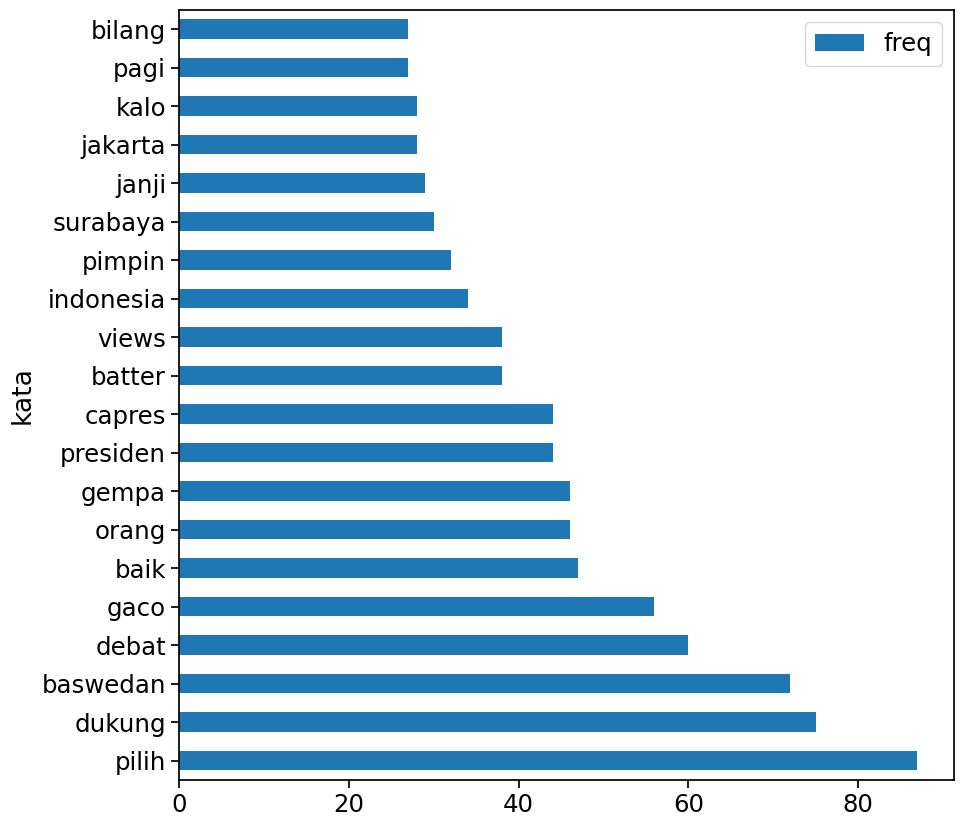

In [57]:
sns.set_context(context = 'notebook', font_scale = 1.6)
kamus_unclean_anies[:20].plot(kind = 'barh',figsize = (10,10))

<Axes: ylabel='kata'>

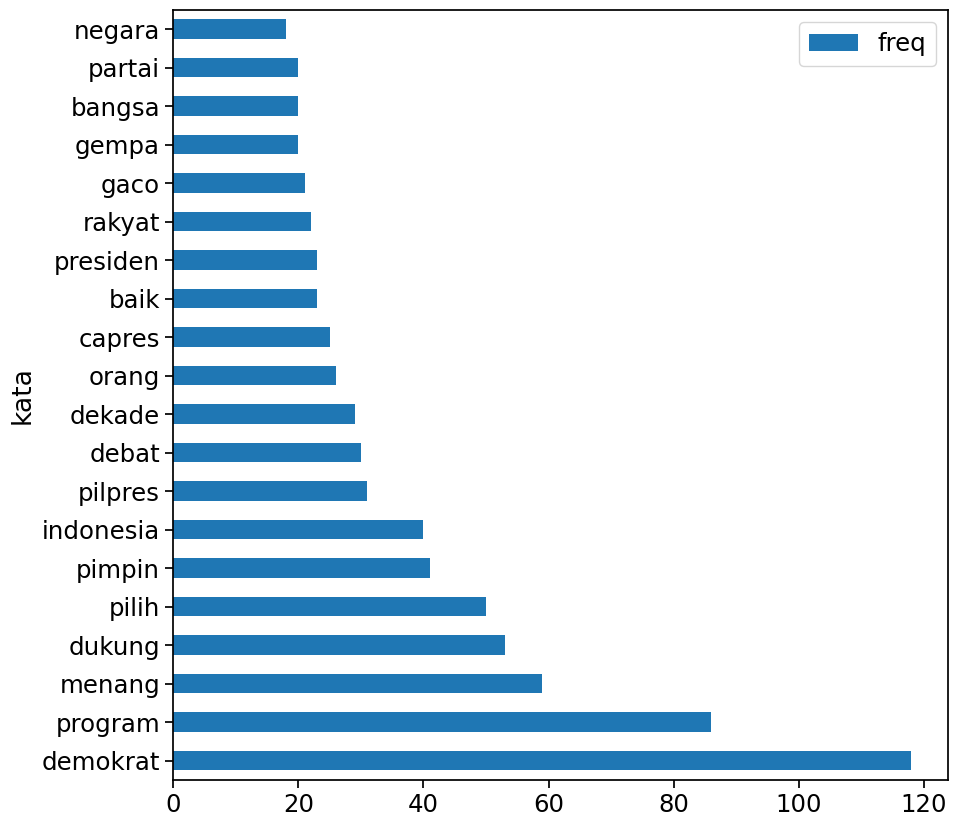

In [58]:
sns.set_context(context = 'notebook', font_scale = 1.6)
kamus_unclean_prabowo[:20].plot(kind = 'barh',figsize = (10,10))

<Axes: ylabel='kata'>

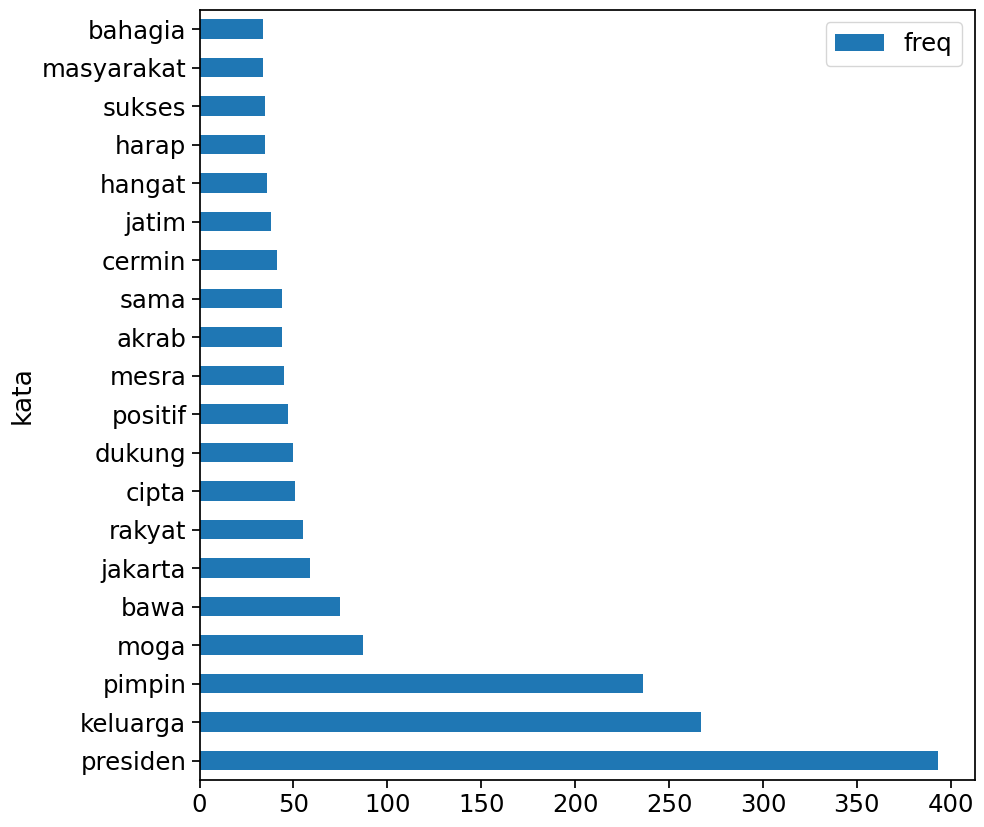

In [59]:
sns.set_context(context = 'notebook', font_scale = 1.6)
kamus_unclean_ganjar[:20].plot(kind = 'barh',figsize = (10,10))

##DARI VISUALISASI DATA DIATAS DAPAT DISIMPULKAN :
*   PASLON ANIES BASWEDAN DAN CAK IMIN:Sytemen yang paling banyak diungkapkan pengguna twitter adalah kata Dukung, Pilih dan debat
*   Paslon Prabowo dan Gibran : Sytemen yang paling banyak diungkapkan pengguna twitter adalah kata Demokrat, bareng, program
*   Paslon Ganjar dan Mahfud MD :Sytemen yang paling banyak diungkapkan pengguna twitter adalah kata presidenn, keluarga, pimpin

## WORD CLOUD
Visualisasi kata yang paling sering muncul dari setiap pasangan calon pemilu 2024

In [60]:
%pip install wordcloud

In [61]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [62]:
def plot_cloud(wordcloud):
    # Set figure size
    plt.figure(figsize=(20, 10))
    # Display image
    plt.imshow(wordcloud)
    # No axis details
    plt.axis("off")

In [63]:
kamus_unclean_anies = df_anies['full_text']
kamus_unclean_prabowo = df_prabowo['full_text']
kamus_unclean_ganjar = df_ganjar['full_text']

In [64]:
word_cloud_anies = WordCloud().generate(df_anies['full_text'].str.cat(sep=' '))
word_cloud_prabowo = WordCloud().generate(df_prabowo['full_text'].str.cat(sep=' '))
word_cloud_ganjar = WordCloud().generate(df_ganjar['full_text'].str.cat(sep=' '))

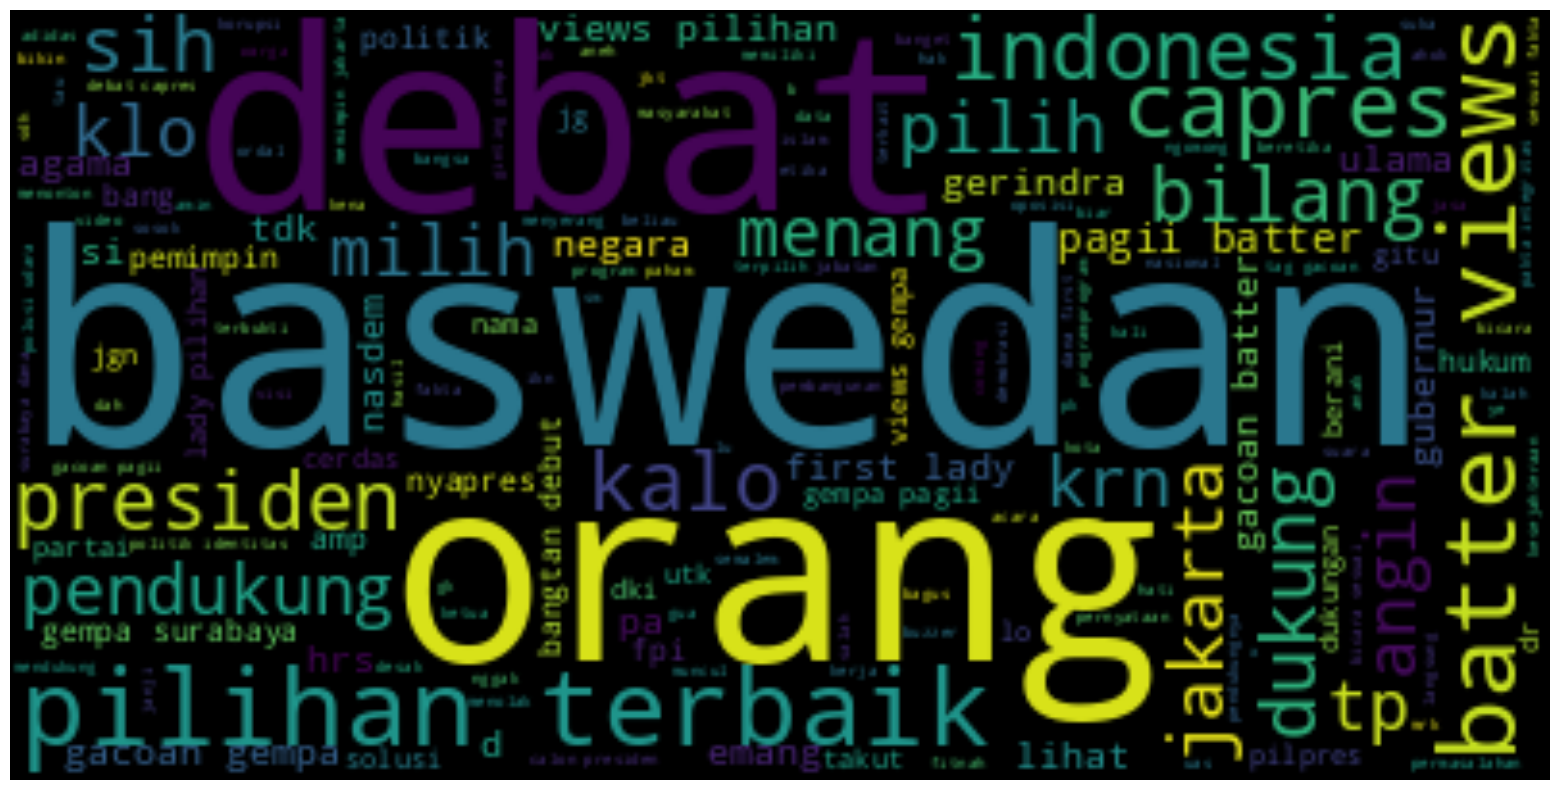

In [65]:
plt.figure(figsize=(20, 10))
plt.imshow(word_cloud_anies, interpolation='bilinear')
plt.axis('off')  # Menonaktifkan axis
plt.show()

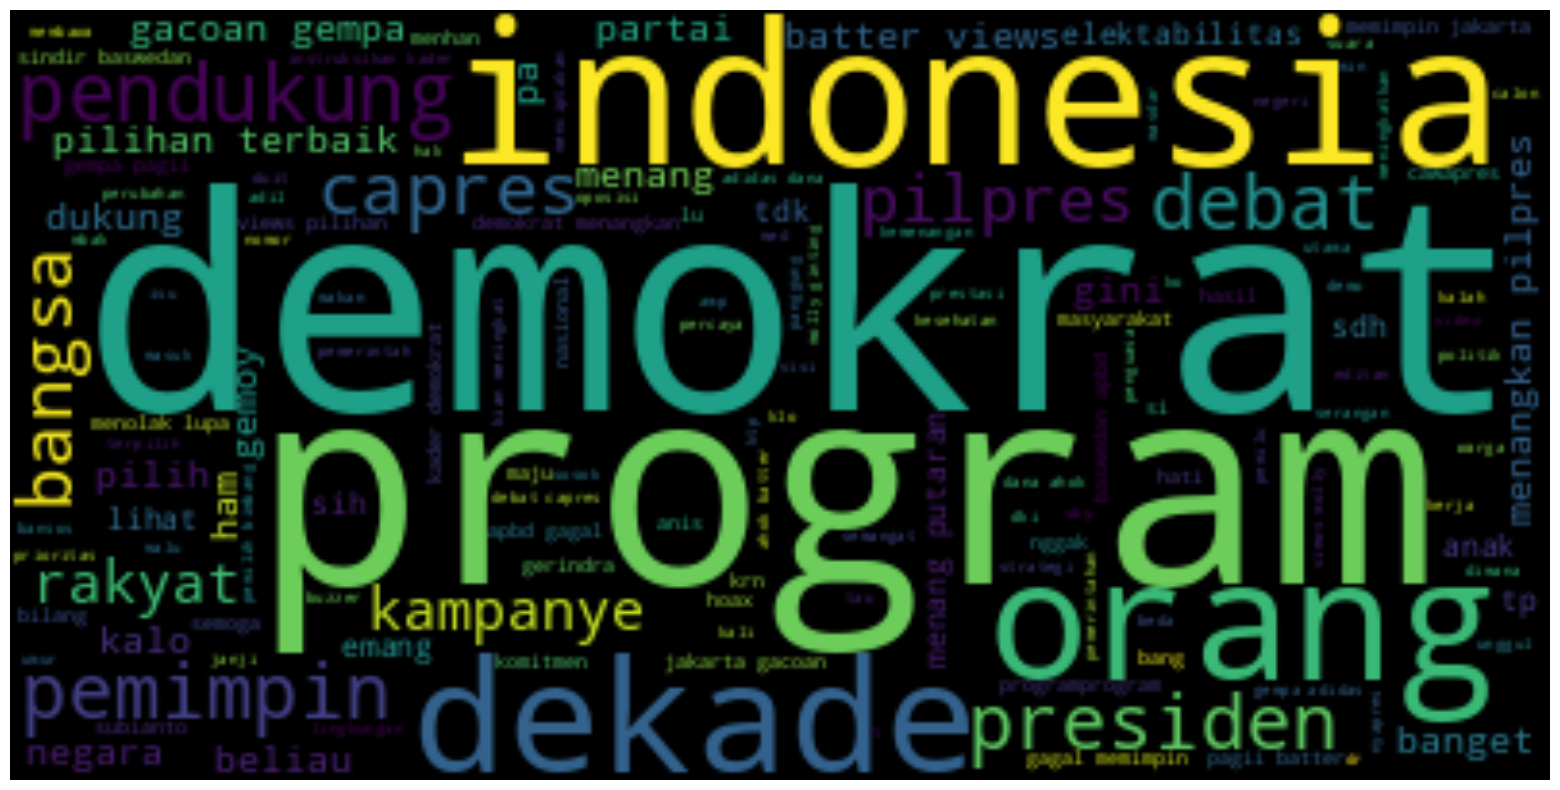

In [66]:
plt.figure(figsize=(20, 10))
plt.imshow(word_cloud_prabowo, interpolation='bilinear')
plt.axis('off')  # Menonaktifkan axis
plt.show()

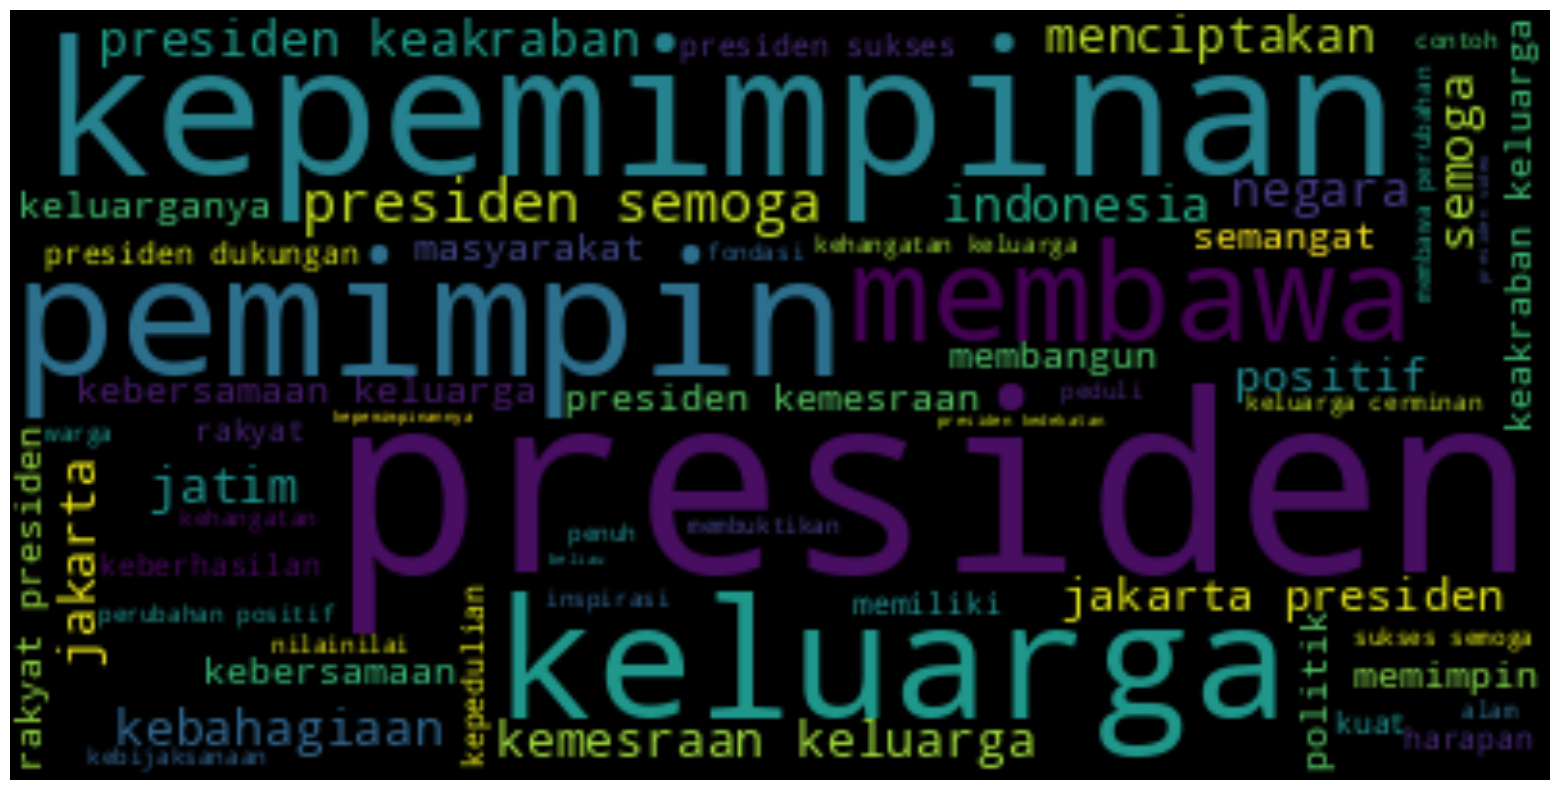

In [67]:
plt.figure(figsize=(20, 10))
plt.imshow(word_cloud_ganjar, interpolation='bilinear')
plt.axis('off')  # Menonaktifkan axis
plt.show()

In [71]:
df_anies.to_csv('df_anies_clean.csv', index=False)
df_prabowo.to_csv('df_prabowo_clean.csv', index=False)
df_ganjar.to_csv('df_ganjar_clean.csv', index=False)

## KESIMPULAN
Dari data diatas maka kita dapat menyimpulkan:

1.   Dari analisis teks terhadap tweet tentang Anies, Ganjar, dan Prabowo, ditemukan bahwa kata-kata yang sering muncul berkaitan dengan isu-isu politik, pimpin, debat, program kerja, serta respons masyarakat terhadap pernyataan atau tindakan mereka.
2.   Kata-kata populer seperti presiden, dukung, debat, dan pilih sering muncul di ketiga tokoh.
3.   Analisis sentimen dapat membantu memetakan persepsi masyarakat terhadap calon pemimpin negara secara objektif dan berbasis data.




In [84]:
from google.colab import files
uploaded = files.upload()

Saving analisa-textual-syntemen-1b20c2f9a753.json to analisa-textual-syntemen-1b20c2f9a753.json


In [89]:
from google.cloud import bigquery
from google.oauth2 import service_account
import pandas_gbq
import pandas as pd

dataset_anies = pd.read_csv('df_anies_clean.csv')
dataset_prabowo = pd.read_csv('df_prabowo_clean.csv')
dataset_ganjar = pd.read_csv('df_ganjar_clean.csv')

project_id = 'analisa-textual-syntemen'
dataset_id = 'analisa_sentimen_capres_2024'

# Jika jalanin di Google Colab, pastikan upload dulu file json-nya
ey_path = r'analisa-textual-syntemen-1b20c2f9a753.json'

scopes = ['https://www.googleapis.com/auth/bigquery']
credentials = service_account.Credentials.from_service_account_file(key_path, scopes=scopes)

# Kirim satu dataset dulu untuk testing
pandas_gbq.to_gbq(dataset_anies, f'{dataset_id}.anies', project_id=project_id, if_exists='replace', credentials=credentials)
pandas_gbq.to_gbq(dataset_prabowo, f'{dataset_id}.prabowo', project_id=project_id, if_exists='replace', credentials=credentials)
pandas_gbq.to_gbq(dataset_ganjar, f'{dataset_id}.ganjar', project_id=project_id, if_exists='replace', credentials=credentials)

GenericGBQException: Reason: 403 POST https://bigquery.googleapis.com/bigquery/v2/projects/analisa-textual-syntemen/datasets?prettyPrint=false: Access Denied: Project analisa-textual-syntemen: User does not have bigquery.datasets.create permission in project analisa-textual-syntemen.